## Food image classisifier

In notebook, we'll build a food image classifier in ***PyTorch*** and compare the performance to a pre-trained model. Th classifier we build will then be used in the ***ExplainableML*** notebook to show how the ***LIME*** image explainer can be used to visualize what the model is paying the most attention to in order to assign the class label. But before we dive into building the classifier, we have some data wrangling to do.

### The dataset

The data used for this project was taken from the Hugging Face hub at:  
https://huggingface.co/datasets/ewanlong/Food_Classification_Dataset/blob/main/Food_Classification_Dataset.zip

The model card describes the data as follows:

+ Dataset Name: 'Food Image Classification Dataset'
+ Dataset Size: 24K unique images
+ Dataset Description: 35 varieties of both Indian and Western appetizers
+ Dataset Source: The unique images obtained from various Google resources by Kaggle user Harish Kumar
+ Dataset License: CC0: Public Domain
+ Dataset Quality:
  - Meticulously curated images ensuring diversity and representativeness
  - Provides a solid foundation for developing robust and precise image classification algorithms
  - Encourages exploration in the fascinating field of food image classification
+ Expected Update Frequency: Quarterly

The data was downloaded so that processing could be done locally. The first thing one notices is that the images are different sizes. Because we will be building a (convolutional) neural network (CNN) classifier, our model will be expecting inputs that are the same size. One practical way to handle this constraint is to resize the images to a pre-determined size. This requires us to decide on the size we should normalize our images to.

### Image size selection

Picking our image size requires us to balance two opposing objectives:

+ The smaller our chosen size, the more data that is lost from the larger images.
+ The larger our chosen size, the more distortion we inject into the smaller images.

One reasonable appoach would be to select the mean image size. We'll need to iterate through the images and save their sizes.

### Classification target

We'll work on a binary classification model which will use a subset of these images. The two target classes will be ***dessert*** and ***not dessert***. For the ***dessert*** target class, we'll gather the following images: **apple_pie**, **cheesecake**, **Donut** and **ice_cream**. For the ***not dessert*** target class, we'll gather the following images: **Crispy Chicken**, **Hot Dog** and **Sandwich**. There are 4500 images in the dessert (positive) class and 4548 images in the ***not dessert*** class, so they are well-balanced.


In [1]:

# set the target folders
dessert_dirs = ["apple_pie", "cheesecake", "Donut", "ice_cream"]  # 4500 images
dessert_dirs_paths = []
dessert_image_files = []
dessert_image_widths = []
dessert_image_heights = []
dessert_image_target = []
dessert_original_class = []

not_dessert_dirs = ["Crispy Chicken", "Hot Dog", "Sandwich"]  # 4548 images
not_dessert_dirs_paths = []
not_dessert_image_files = []
not_dessert_image_widths = []
not_dessert_image_heights = []
not_dessert_image_target = []
not_dessert_original_class = []

In [2]:
from pathlib import Path
# read through the image files and collect their sizes
img_dir = "C:/fast_data/Food_Classification_Dataset"

dir_path = Path(img_dir)
# collect the subset of images used for this analysis
for file_path in dir_path.iterdir():
    if file_path.is_dir and file_path.parts[-1] in dessert_dirs:
        # print(f"adding {file_path} to desserts dir paths")
        dessert_dirs_paths.append(file_path)
    if file_path.is_dir and file_path.parts[-1] in not_dessert_dirs:
        # print(f"adding {file_path} to NOT desserts dir paths")
        not_dessert_dirs_paths.append(file_path)

In [3]:
from PIL import Image
import pandas as pd
# iterate through each image folder and gather the size of each image
# start with positive class image stats
for i, im_path in enumerate(dessert_dirs_paths):
    # get sizes of each image
    dessert_subdir = Path(im_path)
    print(f"*** working on dir: {dessert_subdir} ***")
    for dessert_img_path in dessert_subdir.iterdir():
        dessert_image_files.append(dessert_img_path)
        img = Image.open(dessert_img_path)
        dessert_image_widths.append(img.size[0])
        dessert_image_heights.append(img.size[1])
        dessert_image_target.append(1)
        dessert_original_class.append(dessert_dirs[i])
        # print(f"path: {dessert_img_path} | Original size: {img.size[0], img.size[1]}")
# load the negative class image stats
for i, im_path in enumerate(not_dessert_dirs_paths):
    # get sizes of each image
    not_dessert_subdir = Path(im_path)
    print(f"*** working on dir: {not_dessert_subdir} ***")
    for not_dessert_img_path in not_dessert_subdir.iterdir():
        not_dessert_image_files.append(dessert_img_path)
        img = Image.open(not_dessert_img_path)
        not_dessert_image_widths.append(img.size[0])
        not_dessert_image_heights.append(img.size[1])
        not_dessert_image_target.append(0)
        not_dessert_original_class.append(not_dessert_dirs[i])
        # print(f"path: {not_dessert_img_path} | Original size: {img.size[0], img.size[1]}")

# create consolidated dataframe and export
all_paths = dessert_image_files
all_paths.extend(not_dessert_image_files)
original_class = dessert_original_class
original_class.extend(not_dessert_original_class)
target = dessert_image_target
target.extend(not_dessert_image_target)
widths = dessert_image_widths
widths.extend(not_dessert_image_widths)
heights = dessert_image_heights
heights.extend(not_dessert_image_heights)

# print(f"length: {len(height)} | first: {height[0]}")

df_images = pd.DataFrame({"path": all_paths,
                          "original_class": original_class,
                          "target": target,
                          "width": widths,
                          "height": heights})
# print(df_images.head(5))
# print(df_images.tail(5))

*** working on dir: C:\fast_data\Food_Classification_Dataset\apple_pie ***
*** working on dir: C:\fast_data\Food_Classification_Dataset\cheesecake ***
*** working on dir: C:\fast_data\Food_Classification_Dataset\Donut ***
*** working on dir: C:\fast_data\Food_Classification_Dataset\ice_cream ***
*** working on dir: C:\fast_data\Food_Classification_Dataset\Crispy Chicken ***
*** working on dir: C:\fast_data\Food_Classification_Dataset\Hot Dog ***
*** working on dir: C:\fast_data\Food_Classification_Dataset\Sandwich ***


## Visualize the class distributions

Our intital look at the class size distributions shown below indicates we have a few large images that are distorting our view of these distributions. When we remove images with a height or width larger than 700 pixels (cell 5), we only remove about 0.1% of the data (174) and the contours of the distribution are easier to see (cell 6)

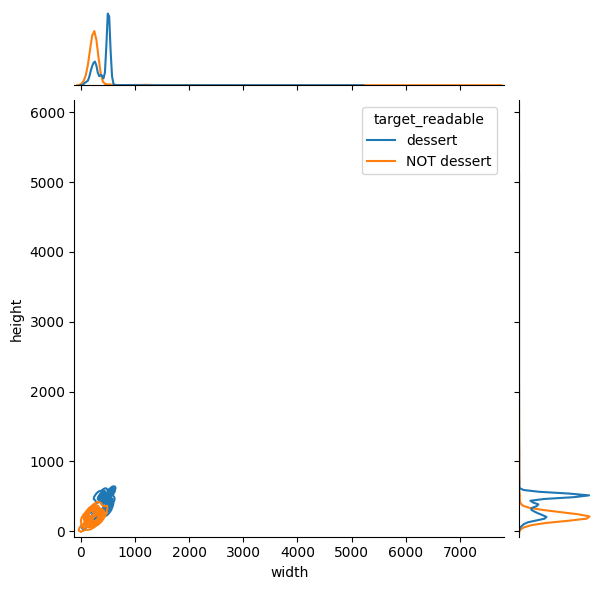

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df_images['target_readable'] = df_images['target'].apply(lambda x: "dessert" if x == 1 else "NOT dessert")

sns.jointplot(
    data=df_images,
    x="width", y="height",
    hue="target_readable", kind="kde"
)

plt.show()  # looks like we have some large outlier images

## Drop the large outlier images

We'll only do this to improve the visualization. We'll keep those larger images and resize them with the rest of the data.

In [5]:
thresh = 700
df_images_trimmed = df_images.loc[(df_images["width"] <= thresh) & (df_images["height"] <= thresh), :]
df_images_trimmed.shape  # (8917, 5) so we only lost 9048 - 8917 = 131 images
print(f"Filtered out {df_images.shape[0] - df_images_trimmed.shape[0]} images at threshold of {thresh} or above")

Filtered out 174 images at threshold of 700 or above


Mean class 0 size: (240.95, 210.2)
Mean class 1 size: (409.18, 387.52)
Overall Mean size: (325.25, 299.06)


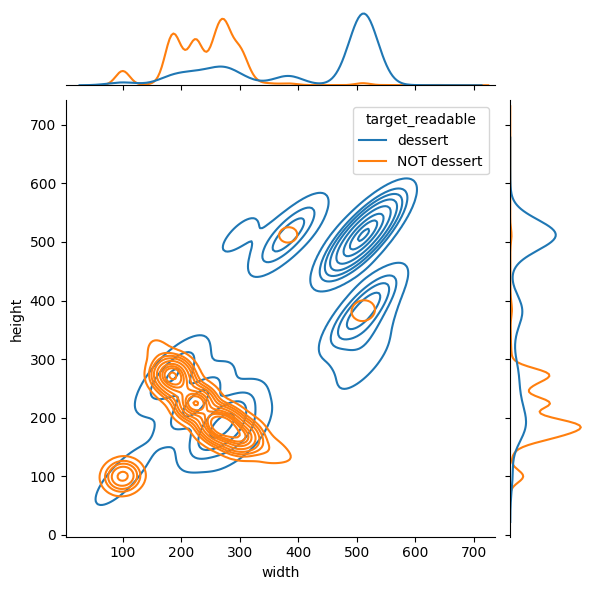

In [6]:
joint_plot = sns.jointplot(
    data=df_images_trimmed,
    x="width", y="height",
    hue="target_readable", kind="kde"
)

# compute means with the outlier removed
mean_class_0_width = df_images_trimmed.loc[df_images_trimmed["target"] == 0, ["width"]].mean()["width"]
mean_class_0_height = df_images_trimmed.loc[df_images_trimmed["target"] == 0, ["height"]].mean()["height"]
mean_class_1_width = df_images_trimmed.loc[df_images_trimmed["target"] == 1, ["width"]].mean()["width"]
mean_class_1_height = df_images_trimmed.loc[df_images_trimmed["target"] == 1, ["height"]].mean()["height"]
mean_width = df_images_trimmed.loc[:, ["width"]].mean()["width"]
mean_height = df_images_trimmed.loc[:, ["height"]].mean()["height"]

# print class and overall means
print(f"Mean class 0 size: {(round(mean_class_0_width.item(), 2), round(mean_class_0_height.item(), 2))}")
print(f"Mean class 1 size: {(round(mean_class_1_width.item(), 2), round(mean_class_1_height.item(), 2))}")
print(f"Overall Mean size: {(round(mean_width.item(), 2), round(mean_height.item(), 2))}")

plt.show()

## Comparing the target distributions

Looks like the positive class (dessert) images tend to be larger than the negative class images (not dessert).

## Overall mean

TODO

## Data wrangling into Torchvison-friendly format

The `torchvision` library is designed to work well with PyTorch, but it expects the following structure:

```
data/
    train/
        class1/
            img0001.png
            img0002.png
            ...
        class2/
            img0001.png
            img0002.png
            ...
        classN/
            ...
    test/
        class1/
            img1001.png
            img1002.png
            ...
        class2/
            img1001.png
            img1002.png
            ...
        classN/
            ...
```

The original data is organized into a parent folder with 34 subfolders each representing different food categories. The structure looks like this:

```
data/
    class1/
        img0001.png
        img0002.png
        ...
    class2/
        img0001.png
        img0002.png
        ...
    classN/
            ...
```

Notice that the `train` and `test` folders of the data we have do not exist. This means we have a little wrangling to do in order to get the data into the ***torchvision-friendly*** structure. The function in the next was used to split the data and put the split data into the appropriate foldsers. The 2 cells that follow the function only needed to be run once, so they were commented out after data splitting was complete.

In [7]:
import os
import random
import shutil

def make_train_test_split(source_dir, target_dir, fraction_to_move):
    """
    Randomly selects a fraction of the files in source_dir equal to fraction_to_move 
    and then moves those files to target_dir.

    Preconditions:
        The source_dir is assumed to have 
    
    Args:
        source_dir (str): path to directory holding the files to move
        target_dir (str): path to directory where files are to be moved to
        fraction_to_move (float): the fraction of files in the source_dir which are 
                                  to be moved to target_dir. Value must be between 
                                  0 (no files to move) and 1 (all files are moved)
                                  
    Returns:
        tuple (int, int): a 2-tuple where the first value is the original number of 
                          files in source_dir and the second value is the number 
                          of files that were moved to target_dir
    """
    # Create the target directory if it does not exist
    os.makedirs(target_dir, exist_ok=True)
    
    # Get all items in the source directory and filter for files only
    all_items = os.listdir(source_dir)
    source_files = [item for item in all_items if os.path.isfile(os.path.join(source_dir, item))]
    
    original_source_files_count = len(source_files)
    files_to_move_count = round(original_source_files_count * fraction_to_move)
    
    # Randomly select the specific number of files to move
    files_to_move = random.sample(source_files, files_to_move_count)
    
    # Move the selected files
    for file_name in files_to_move:
        src_path = os.path.join(source_dir, file_name)
        dst_path = os.path.join(target_dir, file_name)
        shutil.move(src_path, dst_path)
        
    files_moved_to_target = len(files_to_move)
    
    return (original_source_files_count, files_moved_to_target)

In [8]:
# # 80/20 train/test split, class 0 (not dessert)
# s_dir = "C:/data/BinaryFood/not_dessert"
# t_dir = "C:/data/BinaryFood/test/not_dessert"
# # move 20% class 0 to class 0 test
# move_result = move_to_split_dir(source_dir=s_dir, target_dir=t_dir, fraction_to_move=0.2)
# print(f"{move_result[1]} files were moved from {s_dir} to {t_dir}")
# # 909 files were moved from C:/data/BinaryFood/not_dessert to C:/data/BinaryFood/test/not_dessert

In [9]:
# # 80/20 train/test split, class 1 (dessert)
# s_dir = "C:/data/BinaryFood/dessert"
# t_dir = "C:/data/BinaryFood/test/dessert"
# # move 20% class 0 to class 1 test
# move_result = move_to_split_dir(source_dir=s_dir, target_dir=t_dir, fraction_to_move=0.2)
# print(f"{move_result[1]} files were moved from {s_dir} to {t_dir}")
# # 900 files were moved from C:/data/BinaryFood/dessert to C:/data/BinaryFood/test/dessert

## CNN image classifier

With data structured properly, we can now focus on building a model to do the classification. The general structure of pre-trained CNN models is shown below:

<img src="./graphics/extract_backbone_from_pretained.png"></img>

We'll fine-tune the pre-trained model using the `vgg16` model following the procedure described here:

https://medium.com/@qakunnath/fine-tuning-a-pre-trained-vgg16-model-for-custom-image-classification-b1fd4bf56aad



In [10]:
import torch
import torch.nn as nn
import torch.optim as optim  # so we can access CrossEntroyLoss and Adam
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm  # display progress

# define hyperparameters
num_classes = 2
batch_size = 32
num_epochs = 10
learning_rate = 0.001

# define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# load dataset
image_data_dir = "C:/fast_data/BinaryFood/"
train_data = datasets.ImageFolder(image_data_dir + "train", transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)

In [11]:
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
# modify the final layer to perform binary classification
# print(len(vgg16.classifier))  # 7 layers, final layer index = 6
# in_features=4096 for last layer from class VGG __init__ in vgg.py
vgg16.classifier[6] = torch.nn.Linear(in_features=4096, out_features=num_classes)

In [12]:
# check for available gpu
import torch

print(f"Torch version: {torch.__version__}")
print(f"Torch CUDA version: {torch.version.cuda}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"-------------------------------------------")
print(f"Number of GPUs: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")


Torch version: 2.6.0+cu124
Torch CUDA version: 12.4
CUDA Available: True
-------------------------------------------
Number of GPUs: 1
GPU: NVIDIA GeForce RTX 2060 is available.


In [ ]:
# define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.parameters(), lr=learning_rate)

# training loop
for epoch in range(num_epochs):
    with tqdm(train_loader, unit="batch") as tepoch:
        for images, labels in tepoch: #train_loader:
            optimizer.zero_grad()
            outputs = vgg16(images)
            loss = criterion(outputs, labels)
            loss.backward()   # compute the gradient
            optimizer.step()  # update weights
            tepoch.set_description(f"Epoch {epoch}")
            tepoch.set_postfix(loss=loss) #, accuracy=accuracy_value)

## ImageNet normalization

https://discuss.pytorch.org/t/discussion-why-normalise-according-to-imagenet-mean-and-std-dev-for-transfer-learning/115670



In [ ]:
# 
vgg = vgg16(weights=VGG16_Weights.DEFAULT)
# extract the backbone - features are the convolutional layers at the front (input) side of the model
vgg_backbone = nn.Sequential(
    *list(vgg.features.children())
)

In [ ]:
# input size of classification layer must match output size of backbone, so extract the backbone's output size
input_dim = nn.Sequential(
    *list(vgg.classifier.children())
)[0].in_features

# print(input_dim)  # 25088

In [ ]:
# create new classifier layer
num_classes = 2  # binary classifier
classifier_layer = nn.Sequential(
    nn.Linear(input_dim, 512),
    nn.ReLU(),
    nn.Linear(512, num_classes)
)

In [ ]:
# bounding box regressor layer
box_regressor = nn.Sequential(
    nn.Linear(input_dim, 32),
    nn.ReLU(),
    nn.Linear(32, 4)
)

In [ ]:
# putting it all together
class ObjectDetectorCNN(nn.Module): 
    def __init__(self): 
        super(ObjectDetectorCNN, self).__init__()  
        vgg = vgg16(weights=VGG16_Weights.DEFAULT) 
        self.backbone = nn.Sequential(*list(vgg.features.children()))  
        input_features = nn.Sequential(*list(vgg.classifier.children()))[0].in_features  
        self.classifier = nn.Sequential( 
            nn.Linear(input_features, 512), 
            nn.ReLU(),
            nn.Linear(512, 2),  # make it a binary classifier explicitly
        )  
        self.box_regressor = nn.Sequential( 
            nn.Linear(input_features, 32), 
            nn.ReLU(),
            nn.Linear(32, 4), 
        )

    def forward(self, x):
        features = self.backbone(x)
        bboxes = self.regressor(features)
        classes = self.classifier(features)
        return bboxes, classes

In [ ]:
# load image and transform pixels to tensors
import torchvision.transforms as transforms
transform = transforms.compose([
   transforms.Resize   
])

# unsqueeze the image to add the batch dimension


# pass image tensor to model



In [ ]:
# run non-max suppresion over model output


# drop bounding boxes on top of the image




In [ ]:
# import torch.nn as nn
# import torch.optim as optim

# class BinaryCNN(nn.Module):
#     def __init__(self, num_classes):
#         super(BinaryCNN, self).__init__()
#         self.conv1 = nn.Conv2d(3, 16, kernel_size=3,
#                                stride=1, padding=1)
#         )